Этап 1 (Немного улучшенный):

Необходимо выделить р пики на экг
Использовать алгоритм пана - томпкинса
В .txt с экг в 9 канале записан сигнал синхронизации (когда 0 происходит запись кадра F когда ничего не происходит)

Распаковка архива:

In [ ]:
import rarfile

# Если unrar.exe не в PATH, укажите путь явно (для Windows)
rarfile.UNRAR_TOOL = r'C:\Program Files\WinRAR\UnRAR.exe'  # укажите ваш путь

# Распаковка архива
with rarfile.RarFile('1.rar') as rf:
    rf.extractall('./')
    print("Архив успешно распакован!")

Архив успешно распакован!


Файл успешно обработан.
Результат сохранен в: C:\Users\mrfla\OneDrive\Documents\ИТМО\2 - Анализ медицинских изображений\Lab_Rats-main\PHASE1_sync_results.txt
Всего пронумеровано кадров: 80645
Прочитано 670300 отсчетов ECG
Частота дискретизации: 1000 Гц

Найдено 2107 R-пиков:
Номера кадров R-пиков:
R-пик  1: кадр 1, время 0.003 сек, RR: N/A
R-пик  2: кадр 15, время 0.141 сек, RR: 138.0 мс
R-пик  3: кадр 51, время 0.502 сек, RR: 361.0 мс
R-пик  4: кадр 91, время 0.907 сек, RR: 405.0 мс
R-пик  5: кадр 105, время 1.045 сек, RR: 138.0 мс
R-пик  6: кадр 271, время 2.707 сек, RR: 1662.0 мс
R-пик  7: кадр 285, время 2.842 сек, RR: 135.0 мс
R-пик  8: кадр 577, время 5.767 сек, RR: 2925.0 мс
R-пик  9: кадр 591, время 5.906 сек, RR: 139.0 мс
R-пик 10: кадр 606, время 6.054 сек, RR: 148.0 мс
R-пик 11: кадр 897, время 8.961 сек, RR: 2907.0 мс
R-пик 12: кадр 1001, время 10.005 сек, RR: 1044.0 мс
R-пик 13: кадр 1135, время 11.342 сек, RR: 1337.0 мс
R-пик 14: кадр 1148, время 11.479 сек, RR: 137.0 мс


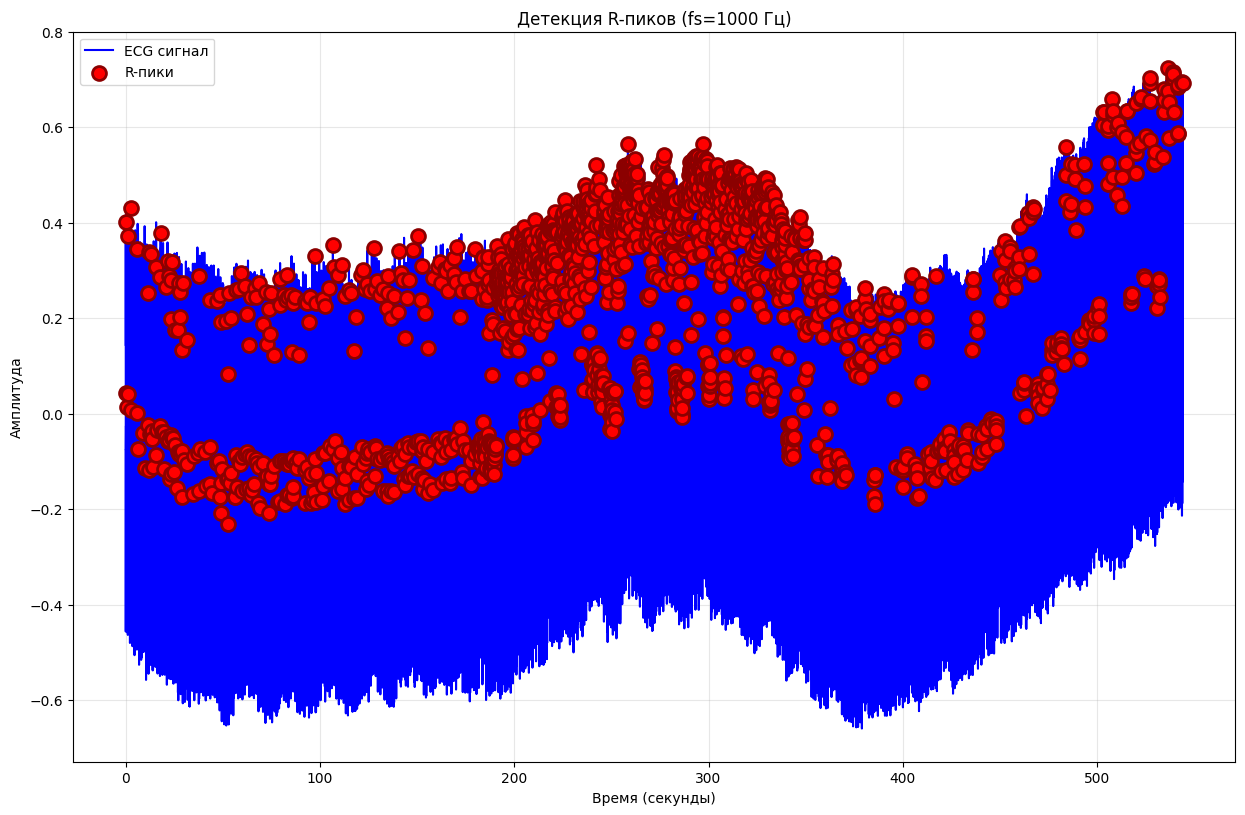


Финальные результаты:
R-пик  1: кадр 1, время 0.003 сек
R-пик  2: кадр 15, время 0.141 сек
R-пик  3: кадр 51, время 0.502 сек
R-пик  4: кадр 91, время 0.907 сек
R-пик  5: кадр 105, время 1.045 сек
R-пик  6: кадр 271, время 2.707 сек
R-пик  7: кадр 285, время 2.842 сек
R-пик  8: кадр 577, время 5.767 сек
R-пик  9: кадр 591, время 5.906 сек
R-пик 10: кадр 606, время 6.054 сек
R-пик 11: кадр 897, время 8.961 сек
R-пик 12: кадр 1001, время 10.005 сек
R-пик 13: кадр 1135, время 11.342 сек
R-пик 14: кадр 1148, время 11.479 сек
R-пик 15: кадр 1198, время 11.975 сек
R-пик 16: кадр 1207, время 12.062 сек
R-пик 17: кадр 1256, время 12.550 сек
R-пик 18: кадр 1314, время 13.137 сек
R-пик 19: кадр 1328, время 13.272 сек
R-пик 20: кадр 1363, время 13.628 сек
R-пик 21: кадр 1378, время 13.773 сек
R-пик 22: кадр 1573, время 15.728 сек
R-пик 23: кадр 1582, время 15.816 сек
R-пик 24: кадр 1596, время 15.951 сек
R-пик 25: кадр 1743, время 17.421 сек
R-пик 26: кадр 1756, время 17.559 сек
R-пик 27: кадр 1

In [12]:
# =========================================================
# НАСТРОЙКА ФАЙЛОВ И ПАРАМЕТРОВ
# =========================================================

# Исходный ECG txt файл
INPUT_FILE = r"C:\Users\mrfla\OneDrive\Documents\ИТМО\2 - Анализ медицинских изображений\Rat1\1\rat8s6e1\pointsString_80.txt"

# Файл после синхронизации
OUTPUT_SYNC_FILE = r"C:\Users\mrfla\OneDrive\Documents\ИТМО\2 - Анализ медицинских изображений\Lab_Rats-main\PHASE1_sync_results.txt"

# Файл с результатами R-пиков
OUTPUT_R_PEAKS_FILE = r"C:\Users\mrfla\OneDrive\Documents\ИТМО\2 - Анализ медицинских изображений\Lab_Rats-main\PHASE1_r_peaks_results.txt"

# Частоты
ECG_FS = 1000
CAM_FPS = 100


# =========================================================
# ИМПОРТ БИБЛИОТЕК
# =========================================================

import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor, Button
import matplotlib as mpl


# =========================================================
# СИНХРОНИЗАЦИЯ КАДРОВ И ECG
# =========================================================

def process_file(input_file, output_file, ecg_fs=1000, cam_fps=100):
    """
    Присваивает номера кадров каждому отсчету ЭКГ.
    - 1 кадр камеры = 10 отсчетов ЭКГ
    - При нарушении синхронизации кадр пустой
    - После восстановления синхронизации начинается новый кадр
    """

    try:
        samples_per_frame = ecg_fs // cam_fps

        frame_number = 1
        counter_in_frame = 0
        sync_active = True

        with open(input_file, 'r', encoding='utf-8') as infile, \
             open(output_file, 'w', encoding='utf-8') as outfile:

            for line in infile:

                columns = line.strip().split()

                if len(columns) < 10:
                    continue

                second_column = columns[1]
                tenth_column = columns[9]

                if tenth_column == "0x00000000":

                    # Потеря синхронизации
                    sync_active = False
                    current_frame = ""
                    counter_in_frame = 0

                else:

                    if not sync_active:

                        # Восстановление синхронизации
                        sync_active = True
                        frame_number += 1

                        counter_in_frame = 1
                        current_frame = frame_number

                    else:

                        # Продолжаем текущий кадр
                        counter_in_frame += 1
                        current_frame = frame_number

                    # Каждые 10 отсчетов — новый кадр
                    if counter_in_frame >= samples_per_frame:
                        frame_number += 1
                        counter_in_frame = 0

                outfile.write(
                    f"{second_column} "
                    f"{tenth_column} "
                    f"{current_frame}\n"
                )

        print(f"Файл успешно обработан.")
        print(f"Результат сохранен в: {output_file}")
        print(f"Всего пронумеровано кадров: {frame_number - 1}")

    except FileNotFoundError:
        print(f"Ошибка: Файл '{input_file}' не найден.")

    except Exception as e:
        print(f"Произошла ошибка: {e}")


# =========================================================
# ЧТЕНИЕ ECG
# =========================================================

def read_ecg_data(filename):

    ecg_data = []
    frame_numbers = []

    with open(filename, 'r') as file:

        for line in file:

            parts = line.strip().split()

            if len(parts) >= 3:

                ecg_value = int(parts[0], 16)
                frame_num = int(parts[2])

                ecg_data.append(ecg_value)
                frame_numbers.append(frame_num)

    return np.array(ecg_data), np.array(frame_numbers)


# =========================================================
# ПРЕДОБРАБОТКА ECG
# =========================================================

def preprocess_ecg_signal(ecg_signal):

    ecg_centered = ecg_signal - np.mean(ecg_signal)

    max_abs = np.max(np.abs(ecg_centered))

    if max_abs > 0:
        ecg_normalized = ecg_centered / max_abs
    else:
        ecg_normalized = ecg_centered

    return ecg_normalized


# =========================================================
# PAN-TOMPKINS
# =========================================================

def pan_tompkins(ecg_signal, fs=1000):

    nyquist = 0.5 * fs

    low = 10.0 / nyquist
    high = 40.0 / nyquist

    b, a = butter(1, [low, high], btype='band')

    filtered_ecg = filtfilt(b, a, ecg_signal)

    # Дифференцирование
    diff_ecg = np.diff(filtered_ecg)
    diff_ecg = np.append(diff_ecg, diff_ecg[-1])

    # Возведение в квадрат
    squared_ecg = diff_ecg ** 2

    # Интегрирование
    window_size = int(0.08 * fs)

    integrated_ecg = np.convolve(
        squared_ecg,
        np.ones(window_size) / window_size,
        mode='same'
    )

    # Поиск пиков
    r_peaks_indices = []

    refractory_period = int(0.1 * fs)

    threshold = np.percentile(integrated_ecg, 0)

    for i in range(1, len(integrated_ecg) - 1):

        if len(r_peaks_indices) > 0 and \
           (i - r_peaks_indices[-1]) < refractory_period:
            continue

        if (integrated_ecg[i] > threshold and
                integrated_ecg[i] > integrated_ecg[i - 1] and
                integrated_ecg[i] > integrated_ecg[i + 1]):

            search_window = int(0.04 * fs)

            search_start = max(0, i - search_window)
            search_end = min(len(ecg_signal) - 1, i + search_window)

            exact_peak = np.argmax(
                ecg_signal[search_start:search_end]
            ) + search_start

            r_peaks_indices.append(exact_peak)

    return r_peaks_indices


# =========================================================
# ВАЛИДАЦИЯ R-ПИКОВ
# =========================================================

def validate_r_peaks(r_peaks_indices, fs=1000):

    if len(r_peaks_indices) < 2:
        return r_peaks_indices

    valid_peaks = [r_peaks_indices[0]]

    min_rr_interval = int(0.06 * fs)
    max_rr_interval = int(0.15 * fs)

    for i in range(1, len(r_peaks_indices)):

        rr_interval = (
            r_peaks_indices[i] -
            r_peaks_indices[i - 1]
        )

        if min_rr_interval <= rr_interval <= max_rr_interval:
            valid_peaks.append(r_peaks_indices[i])

    return valid_peaks


# =========================================================
# ДЕТЕКЦИЯ R-ПИКОВ
# =========================================================

def detect_r_peaks_from_file(filename, fs=1000):

    ecg_signal, frame_numbers = read_ecg_data(filename)

    print(f"Прочитано {len(ecg_signal)} отсчетов ECG")
    print(f"Частота дискретизации: {fs} Гц")

    ecg_signal = preprocess_ecg_signal(ecg_signal)

    r_peaks_indices = pan_tompkins(ecg_signal, fs)

    r_peaks_indices = validate_r_peaks(
        r_peaks_indices,
        fs
    )

    r_peak_frames = frame_numbers[r_peaks_indices]

    print(f"\nНайдено {len(r_peaks_indices)} R-пиков:")
    print("Номера кадров R-пиков:")

    for i, (frame, index) in enumerate(
            zip(r_peak_frames, r_peaks_indices)):

        time_sec = index / fs

        rr_interval = (
            "N/A"
            if i == 0
            else f"{(r_peaks_indices[i] - r_peaks_indices[i - 1]) / fs * 1000:.1f} мс"
        )

        print(
            f"R-пик {i + 1:2d}: "
            f"кадр {frame}, "
            f"время {time_sec:.3f} сек, "
            f"RR: {rr_interval}"
        )

    return (
        r_peak_frames,
        r_peaks_indices,
        ecg_signal,
        frame_numbers
    )


# =========================================================
# СОХРАНЕНИЕ R-ПИКОВ
# =========================================================

def save_r_peaks_to_file(
        r_peaks_indices,
        frame_numbers,
        fs=1000,
        filename="r_peaks_results_mouse.txt"
):

    r_peak_frames = frame_numbers[r_peaks_indices]

    with open(filename, "w") as f:

        for i, frame in enumerate(r_peak_frames):

            time_sec = r_peaks_indices[i] / fs

            f.write(f"{frame}\t{time_sec:.3f}\n")

    print(f"Результаты сохранены в файл '{filename}'")

    return r_peak_frames


# =========================================================
# ИНТЕРАКТИВНЫЙ РЕДАКТОР
# =========================================================

class InteractiveRPeakEditor:

    def __init__(
            self,
            ecg_signal,
            r_peaks_indices,
            frame_numbers,
            fs=1000,
            start_second=5,
            end_second=10
    ):

        self.ecg_signal = ecg_signal
        self.r_peaks_indices = r_peaks_indices.copy()
        self.frame_numbers = frame_numbers
        self.fs = fs

        self.start_second = start_second
        self.end_second = end_second

        self.edit_mode = True
        self.dragging = False

        self.fig, self.ax = plt.subplots(figsize=(15, 10))

        self.time = np.arange(len(ecg_signal)) / fs

        plt.subplots_adjust(bottom=0.15)

        self.start_index = max(0, int(start_second * fs))
        self.end_index = min(len(ecg_signal), int(end_second * fs))

        self.display_time = self.time[self.start_index:self.end_index]
        self.display_signal = ecg_signal[self.start_index:self.end_index]
        self.display_frames = frame_numbers[self.start_index:self.end_index]

        self.line, = self.ax.plot(
            self.display_time,
            self.display_signal,
            label='ECG сигнал',
            linewidth=1.5,
            color='blue'
        )

        self.update_r_peaks_display()

        self.cursor = Cursor(
            self.ax,
            useblit=True,
            color='red',
            linewidth=1
        )

        self.setup_plot()

    def setup_plot(self):

        self.ax.set_xlabel('Время (секунды)')
        self.ax.set_ylabel('Амплитуда')

        self.ax.set_title(
            f'Детекция R-пиков '
            f'(fs={self.fs} Гц)'
        )

        self.ax.legend()
        self.ax.grid(True, alpha=0.3)

    def update_r_peaks_display(self):

        display_peaks = [
            idx for idx in self.r_peaks_indices
            if self.start_index <= idx < self.end_index
        ]

        if display_peaks:

            self.ax.scatter(
                self.time[display_peaks],
                self.ecg_signal[display_peaks],
                c='red',
                s=100,
                marker='o',
                edgecolors='darkred',
                linewidths=2,
                label='R-пики',
                zorder=5
            )

    def show(self):

        plt.show()


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================

def plot_results(
        ecg_signal,
        r_peaks_indices,
        frame_numbers,
        fs=1000,
        start_second=5,
        end_second=10
):

    editor = InteractiveRPeakEditor(
        ecg_signal,
        r_peaks_indices,
        frame_numbers,
        fs,
        start_second,
        end_second
    )

    editor.show()

    return editor.r_peaks_indices


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":

    # ЭТАП 1
    process_file(
        INPUT_FILE,
        OUTPUT_SYNC_FILE,
        ecg_fs=ECG_FS,
        cam_fps=CAM_FPS
    )

    filename = OUTPUT_SYNC_FILE

    try:

        (
            r_peak_frames,
            r_peaks_indices,
            ecg_signal,
            frame_numbers
        ) = detect_r_peaks_from_file(
            filename,
            fs=ECG_FS
        )

        save_r_peaks_to_file(
            r_peaks_indices,
            frame_numbers,
            fs=ECG_FS,
            filename=OUTPUT_R_PEAKS_FILE
        )

        updated_r_peaks = plot_results(
            ecg_signal,
            r_peaks_indices,
            frame_numbers,
            fs=ECG_FS,
            start_second=0,
            end_second=544
        )

        print(f"\nФинальные результаты:")

        r_peak_frames_final = frame_numbers[updated_r_peaks]

        for i, (frame, index) in enumerate(
                zip(r_peak_frames_final, updated_r_peaks)):

            time_sec = index / 1000.0

            print(
                f"R-пик {i + 1:2d}: "
                f"кадр {frame}, "
                f"время {time_sec:.3f} сек"
            )

    except FileNotFoundError:

        print(f"Файл {filename} не найден!")

    except Exception as e:

        print(f"Ошибка при обработке данных: {e}")

Этап 2:

По сигналу синхронизации сопоставить кадры с моментом их записи в СИ ЭКГ

In [13]:
import numpy as np

# =========================================================
# ВЫБОР ФАЙЛОВ
# =========================================================

# Файл с синхронизацией (результат первого этапа)
sync_file = r"C:\Users\mrfla\OneDrive\Documents\ИТМО\2 - Анализ медицинских изображений\Lab_Rats-main\PHASE1_sync_results.txt"

# Файл с R-пиками (результат первого этапа)
rpeaks_file = r"C:\Users\mrfla\OneDrive\Documents\ИТМО\2 - Анализ медицинских изображений\Lab_Rats-main\PHASE1_r_peaks_results.txt"

# Куда сохранить результат
output_file = r"C:\Users\mrfla\OneDrive\Documents\ИТМО\2 - Анализ медицинских изображений\Lab_Rats-main\PHASE2_cardio_cycles.txt"


# =========================================================
# ЧТЕНИЕ R-ПИКОВ
# =========================================================

def load_r_peak_frames(filename):
    """
    Загружает номера кадров R-пиков.
    
    Формат файла:
    frame_number    time_sec
    """

    r_peak_frames = []

    with open(filename, "r") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) < 1:
                continue

            try:
                frame = int(parts[0])
                r_peak_frames.append(frame)

            except:
                continue

    return sorted(r_peak_frames)


# =========================================================
# ЧТЕНИЕ ВСЕХ КАДРОВ ИЗ ФАЙЛА СИНХРОНИЗАЦИИ
# =========================================================

def load_all_frames(sync_filename):
    """
    Загружает все номера кадров из sync_results_old.txt
    
    Формат:
    ECG_value   sync_signal   frame_number
    """

    frames = []

    with open(sync_filename, "r") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) < 3:
                continue

            frame_str = parts[2]

            # пустые кадры пропускаем
            if frame_str == "":
                continue

            try:
                frame = int(frame_str)
                frames.append(frame)

            except:
                continue

    # уникальные кадры
    frames = sorted(list(set(frames)))

    return frames


# =========================================================
# РАЗБИЕНИЕ НА КАРДИОЦИКЛЫ
# =========================================================

def split_frames_into_cycles(all_frames, r_peak_frames):
    """
    Для каждого кадра определяет:
    к какому кардиоциклу он относится.
    """

    result = []

    cycle_id = 1

    for i in range(len(r_peak_frames) - 1):

        start_frame = r_peak_frames[i]
        end_frame = r_peak_frames[i + 1]

        # выбираем кадры внутри текущего цикла
        cycle_frames = [
            frame for frame in all_frames
            if start_frame <= frame < end_frame
        ]

        for frame in cycle_frames:
            result.append((frame, cycle_id))

        print(
            f"Кардиоцикл {cycle_id:4d}: "
            f"кадры {start_frame} - {end_frame - 1} | "
            f"всего кадров: {len(cycle_frames)}"
        )

        cycle_id += 1

    return result


# =========================================================
# СОХРАНЕНИЕ РЕЗУЛЬТАТА
# =========================================================

def save_cycles(result, filename):
    """
    Сохраняет:
    frame_number    cycle_id
    """

    with open(filename, "w") as f:

        f.write("frame_number\tcycle_id\n")

        for frame, cycle in result:
            f.write(f"{frame}\t{cycle}\n")

    print(f"\nРезультат сохранен в файл:\n{filename}")


# =========================================================
# ОСНОВНАЯ ЧАСТЬ
# =========================================================

if __name__ == "__main__":

    print("Загрузка R-пиков...")
    r_peak_frames = load_r_peak_frames(rpeaks_file)

    print(f"Найдено R-пиков: {len(r_peak_frames)}")

    print("\nЗагрузка кадров...")
    all_frames = load_all_frames(sync_file)

    print(f"Всего кадров: {len(all_frames)}")

    print("\nРазбиение на кардиоциклы...")
    cycles_result = split_frames_into_cycles(
        all_frames,
        r_peak_frames
    )

    print(f"\nВсего найдено кардиоциклов: {len(r_peak_frames)-1}")

    print("\nСохранение результата...")
    save_cycles(cycles_result, output_file)

    print("\nГотово.")

Загрузка R-пиков...
Найдено R-пиков: 2107

Загрузка кадров...
Всего кадров: 80646

Разбиение на кардиоциклы...
Кардиоцикл    1: кадры 1 - 14 | всего кадров: 14
Кардиоцикл    2: кадры 15 - 50 | всего кадров: 36
Кардиоцикл    3: кадры 51 - 90 | всего кадров: 40
Кардиоцикл    4: кадры 91 - 104 | всего кадров: 14
Кардиоцикл    5: кадры 105 - 270 | всего кадров: 166
Кардиоцикл    6: кадры 271 - 284 | всего кадров: 14
Кардиоцикл    7: кадры 285 - 576 | всего кадров: 292
Кардиоцикл    8: кадры 577 - 590 | всего кадров: 14
Кардиоцикл    9: кадры 591 - 605 | всего кадров: 15
Кардиоцикл   10: кадры 606 - 896 | всего кадров: 291
Кардиоцикл   11: кадры 897 - 1000 | всего кадров: 104
Кардиоцикл   12: кадры 1001 - 1134 | всего кадров: 134
Кардиоцикл   13: кадры 1135 - 1147 | всего кадров: 13
Кардиоцикл   14: кадры 1148 - 1197 | всего кадров: 50
Кардиоцикл   15: кадры 1198 - 1206 | всего кадров: 9
Кардиоцикл   16: кадры 1207 - 1255 | всего кадров: 49
Кардиоцикл   17: кадры 1256 - 1313 | всего кадров: